# 01 Exploration Strategies

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply ε-greedy, UCB, and similar strategies
- Balance exploration and exploitation

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 4**.

---


## Lesson Brief

This lesson introduces the big exploration question in reinforcement learning: how should an agent balance trying uncertain actions against using what already looks best?

Students will see several exploration strategies and the intuition behind each one.

Why this matters: poor exploration can make even a correct learning algorithm perform badly.

This lesson gives the decision-making lens needed for the rest of Unit 4.

## Recommended YouTube Video

To reinforce this lesson, watch **David Silver - "RL Course Lecture 9: Exploration and Exploitation"**:
[Watch on YouTube](https://www.youtube.com/watch?v=sGuiWX07sKw)

Why this pick:
- Covers the exploration-exploitation dilemma as a central RL problem, not just a coding trick.
- Strong fit for the opening lesson of this unit.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Exploration: trying uncertain actions.
- Exploitation: using the current best action.
- Epsilon: explore probability.
- Regret: the reward lost because the best action was not always chosen.
- Bandit setting: choose an action and get reward, without a full state-transition story.

### Quick Check
- Why is pure exploitation risky early?
- What changes when epsilon is high or low?
- How do the plots reveal the trade-off?
- Why is a bandit a useful teaching simplification before full RL exploration?

### Common Mistakes
- Assuming exploration means permanent randomness.
- Using one lucky run as proof.
- Confusing exploration rate with learning rate.
- Thinking bandit exploration and full RL exploration are exactly the same problem.


## Big Idea

Exploration asks: *Should the agent try something uncertain?*

Exploitation asks: *Should the agent use what currently looks best?*

This notebook introduces the main family of strategies used to balance those two goals.

## Why This Notebook Starts with Bandits

Students sometimes ask why exploration is first explained with a bandit instead of a full MDP.

### The reason

Bandits isolate the exploration-exploitation dilemma very clearly.

- choose an action
- observe a reward
- update your belief about that action

There is no full state-transition chain yet.
That makes it easier to see the decision trade-off before adding the extra difficulty of long-term trajectories.

### What changes in full RL?

In full reinforcement learning, exploration matters even more because actions also change future states.
So the same basic dilemma remains, but the consequences are longer-term and more complicated.

### Teaching takeaway

This notebook teaches the **core intuition** first.
Later RL settings keep the same dilemma, but with more structure around states, trajectories, and delayed effects.

## Learning Path in This Notebook

1. Review the dilemma
2. Compare several exploration strategies conceptually
3. Run a bandit simulation
4. Interpret reward and regret curves

### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Import names from a package/module into the notebook kernel namespace.
import numpy as np
# Import names from a package/module into the notebook kernel namespace.
import matplotlib.pyplot as plt

# Call a NumPy helper (array creation, options, or array conversion).
np.random.seed(42)

# Print text to the notebook cell output (console).
print("✅ Libraries imported!")
# Print text to the notebook cell output (console).
print("\nUnit 4 - Exploration Strategies")
# Print text to the notebook cell output (console).
print("=" * 60)


✅ Libraries imported!

Unit 4 - Exploration Strategies


## Concept Map

- **Epsilon-greedy**: simple random exploration with probability epsilon
- **UCB**: prefers actions with high estimated value *and* high uncertainty
- **Thompson Sampling**: samples from a belief distribution over action quality
- **Curiosity / intrinsic motivation**: rewards novelty or prediction error

### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [2]:
# Teaching note: this cell advances the lesson by building the next piece of the RL workflow.
# Run it after reading the comments so the output feels connected to the concept being taught.

# Assign/update a variable used later in this cell or in other cells.
strategies = {
    # Execute: "epsilon-greedy": "random exploration with fixed or decaying epsilon",
    "epsilon-greedy": "random exploration with fixed or decaying epsilon",
    # Execute: "UCB": "optimism under uncertainty",
    "UCB": "optimism under uncertainty",
    # Execute: "Thompson Sampling": "sample from posterior beliefs",
    "Thompson Sampling": "sample from posterior beliefs",
    # Execute: "curiosity": "reward novelty or prediction error",
    "curiosity": "reward novelty or prediction error",
# Part of a dict/set literal layout (syntax grouping).
}

# Loop header: repeat the indented block for each item in the iterable.
for name, description in strategies.items():
    # Print text to the notebook cell output (console).
    print(f"- {name}: {description}")


- epsilon-greedy: random exploration with fixed or decaying epsilon
- UCB: optimism under uncertainty
- Thompson Sampling: sample from posterior beliefs
- curiosity: reward novelty or prediction error


## What to watch for in the simulation

When you run the example below, ask:

- Which strategy finds the best arm fastest?
- Which strategy wastes the least reward early on?
- Which strategy seems most stable over time?

That is the lens you will later apply in larger RL environments.

## Note

This notebook uses a bandit example because it isolates exploration clearly before
mixing it with value functions, long episodes, and full environment dynamics.

## 🌍 Real-World Worked Example — A/B Testing with Multi-Armed Bandits

**Industry context:**
- Streaming, ads, and product teams do use bandit-style ideas in experimentation
- The exact production systems are usually more complex than the small classroom version shown here
- Treat these examples as realistic application families, not as one-to-one replicas of a company's production stack

We compare **ε-greedy**, **UCB**, and **Thompson Sampling** on a real A/B test simulation.

### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


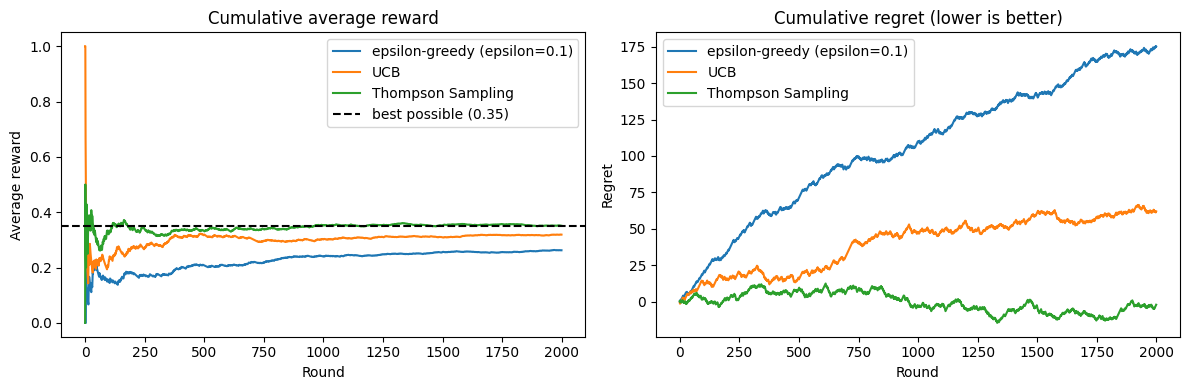

epsilon-greedy (epsilon=0.1): total reward = 525, final avg reward = 0.263
UCB: total reward = 638, final avg reward = 0.319
Thompson Sampling: total reward = 702, final avg reward = 0.351


In [3]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Import names from a package/module into the notebook kernel namespace.
import numpy as np
# Import names from a package/module into the notebook kernel namespace.
import matplotlib.pyplot as plt

# Call a NumPy helper (array creation, options, or array conversion).
np.random.seed(42)
# Assign/update a variable used later in this cell or in other cells.
TRUE_RATES = [0.15, 0.22, 0.35, 0.18, 0.28]
# Assign/update a variable used later in this cell or in other cells.
N_ARMS = len(TRUE_RATES)
# Assign/update a variable used later in this cell or in other cells.
N_ROUNDS = 2000
# Assign/update a variable used later in this cell or in other cells.
BEST_RATE = max(TRUE_RATES)


# Define function `pull`: parameters in parentheses; the indented body below implements its behavior step-by-step.
def pull(arm):
    # Return a value from this function to its caller.
    return 1 if np.random.rand() < TRUE_RATES[arm] else 0


# Define function `epsilon_greedy`: parameters in parentheses; the indented body below implements its behavior step-by-step.
def epsilon_greedy(eps):
    # Assign/update a variable used later in this cell or in other cells.
    counts = np.zeros(N_ARMS)
    # Assign/update a variable used later in this cell or in other cells.
    totals = np.zeros(N_ARMS)
    # Unpack the one-step model output from transition(state, action).
    rewards = []
    # Loop header: repeat the indented block for each item in the iterable.
    for _ in range(N_ROUNDS):
        # Assign/update a variable used later in this cell or in other cells.
        arm = np.random.randint(N_ARMS) if np.random.rand() < eps else np.argmax(totals / (counts + 1e-9))
        # Unpack the one-step model output from transition(state, action).
        reward = pull(arm)
        # Assign/update a variable used later in this cell or in other cells.
        counts[arm] += 1
        # Assign/update a variable used later in this cell or in other cells.
        totals[arm] += reward
        # Append one value to a list (mutates the list in place).
        rewards.append(reward)
    # Return a value from this function to its caller.
    return np.array(rewards)


# Define function `ucb`: parameters in parentheses; the indented body below implements its behavior step-by-step.
def ucb():
    # Assign/update a variable used later in this cell or in other cells.
    counts = np.zeros(N_ARMS)
    # Assign/update a variable used later in this cell or in other cells.
    totals = np.zeros(N_ARMS)
    # Unpack the one-step model output from transition(state, action).
    rewards = []
    # Loop header: repeat the indented block for each item in the iterable.
    for arm in range(N_ARMS):
        # Unpack the one-step model output from transition(state, action).
        reward = pull(arm)
        # Assign/update a variable used later in this cell or in other cells.
        counts[arm] = 1
        # Assign/update a variable used later in this cell or in other cells.
        totals[arm] += reward
        # Append one value to a list (mutates the list in place).
        rewards.append(reward)
    # Loop header: repeat the indented block for each item in the iterable.
    for t in range(N_ARMS, N_ROUNDS):
        # Assign/update a variable used later in this cell or in other cells.
        ucb_vals = totals / counts + np.sqrt(2 * np.log(t + 1) / counts)
        # Assign/update a variable used later in this cell or in other cells.
        arm = np.argmax(ucb_vals)
        # Unpack the one-step model output from transition(state, action).
        reward = pull(arm)
        # Assign/update a variable used later in this cell or in other cells.
        counts[arm] += 1
        # Assign/update a variable used later in this cell or in other cells.
        totals[arm] += reward
        # Append one value to a list (mutates the list in place).
        rewards.append(reward)
    # Return a value from this function to its caller.
    return np.array(rewards)


# Define function `thompson`: parameters in parentheses; the indented body below implements its behavior step-by-step.
def thompson():
    # Assign/update a variable used later in this cell or in other cells.
    alpha = np.ones(N_ARMS)
    # Assign/update a variable used later in this cell or in other cells.
    beta_ = np.ones(N_ARMS)
    # Unpack the one-step model output from transition(state, action).
    rewards = []
    # Loop header: repeat the indented block for each item in the iterable.
    for _ in range(N_ROUNDS):
        # Assign/update a variable used later in this cell or in other cells.
        samples = np.random.beta(alpha, beta_)
        # Assign/update a variable used later in this cell or in other cells.
        arm = np.argmax(samples)
        # Unpack the one-step model output from transition(state, action).
        reward = pull(arm)
        # Branch: only run the next indented lines when this condition is true.
        if reward:
            # Assign/update a variable used later in this cell or in other cells.
            alpha[arm] += 1
        # Else branch: runs when the matching if/elif chain was not taken.
        else:
            # Assign/update a variable used later in this cell or in other cells.
            beta_[arm] += 1
        # Append one value to a list (mutates the list in place).
        rewards.append(reward)
    # Return a value from this function to its caller.
    return np.array(rewards)


# Assign/update a variable used later in this cell or in other cells.
strategies = {
    # Assign/update a variable used later in this cell or in other cells.
    "epsilon-greedy (epsilon=0.1)": epsilon_greedy(0.1),
    # Execute: "UCB": ucb(),
    "UCB": ucb(),
    # Execute: "Thompson Sampling": thompson(),
    "Thompson Sampling": thompson(),
# Part of a dict/set literal layout (syntax grouping).
}


# Define function `cumulative_average`: parameters in parentheses; the indented body below implements its behavior step-by-step.
def cumulative_average(values):
    # Return a value from this function to its caller.
    return np.cumsum(values) / np.arange(1, len(values) + 1)


# Define function `cumulative_regret`: parameters in parentheses; the indented body below implements its behavior step-by-step.
def cumulative_regret(values):
    # Return a value from this function to its caller.
    return np.cumsum(BEST_RATE - values)


# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.figure(figsize=(12, 4))
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.subplot(1, 2, 1)
# Loop header: repeat the indented block for each item in the iterable.
for name, rewards in strategies.items():
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.plot(cumulative_average(rewards), label=name)
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.axhline(BEST_RATE, color="k", linestyle="--", label=f"best possible ({BEST_RATE})")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.title("Cumulative average reward")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.xlabel("Round")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.ylabel("Average reward")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.legend()

# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.subplot(1, 2, 2)
# Loop header: repeat the indented block for each item in the iterable.
for name, rewards in strategies.items():
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.plot(cumulative_regret(rewards), label=name)
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.title("Cumulative regret (lower is better)")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.xlabel("Round")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.ylabel("Regret")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.legend()
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.tight_layout()
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.show()

# Loop header: repeat the indented block for each item in the iterable.
for name, rewards in strategies.items():
    # Print text to the notebook cell output (console).
    print(f"{name}: total reward = {int(rewards.sum())}, final avg reward = {rewards.mean():.3f}")


## 📝 Summary

In this notebook, you learned:
- The **exploration-exploitation trade-off**: why an agent must try new actions to discover better long-term rewards
- **ε-greedy**: take random actions with probability ε, exploit the best known action otherwise — with ε decay over time
- **Upper Confidence Bound (UCB)**: select actions based on both estimated value and uncertainty, ensuring optimism in the face of uncertainty
- **Thompson Sampling**: maintain a probability distribution over each action's value and sample from it to drive exploration

**Next steps:** Apply these exploration strategies inside a full DQN/PPO training loop and observe their effect on sample efficiency in Unit 4 exercises.

## 📚 References & Further Reading

**Book:** Sutton & Barto — [RL Introduction Ch.2: Multi-armed Bandits](http://incompleteideas.net/book/the-book-2nd.html)
**Paper:** Auer et al. (2002) — [Finite-time Analysis of UCB](https://link.springer.com/article/10.1023/A:1013689704352)

**Real-World Usage:**
- Google uses Thompson Sampling in Google Ads for A/B testing at scale
- Netflix uses bandit algorithms to pick which thumbnail to show each user

**State-of-the-Art:** ε-greedy and UCB are still dominant in industry A/B testing systems.

### Step Guide

**What this cell does:** This cell turns the lesson outputs into a final visual recap.

**Why this matters:** Weak coders often understand charts faster than raw arrays or printed dictionaries.

**What to expect in the output:** Expect one or more plots that summarize the most important numbers from the notebook.

**Common student confusion:** Students should use this as a summary view after understanding the earlier steps, not as a replacement for them.


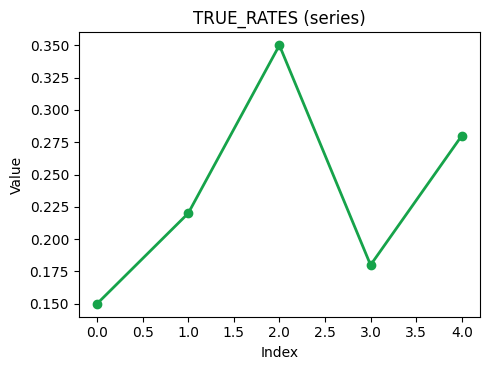

In [4]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Import names from a package/module into the notebook kernel namespace.
import numbers
# Import names from a package/module into the notebook kernel namespace.
import numpy as np
# Import names from a package/module into the notebook kernel namespace.
import matplotlib.pyplot as plt

# Define function `_is_number`: parameters in parentheses; the indented body below implements its behavior step-by-step.
def _is_number(value):
    # Return a value from this function to its caller.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Define function `_as_numeric_dict`: parameters in parentheses; the indented body below implements its behavior step-by-step.
def _as_numeric_dict(value):
    # Branch: only run the next indented lines when this condition is true.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Return a value from this function to its caller.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Loop header: repeat the indented block for each item in the iterable.
    for item in value.values():
        # Branch: only run the next indented lines when this condition is true.
        if not _is_number(item):
            # Return a value from this function to its caller.
            return None
        # Append one value to a list (mutates the list in place).
        converted.append(float(item))
    # Return a value from this function to its caller.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Define function `_as_numeric_array`: parameters in parentheses; the indented body below implements its behavior step-by-step.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if array.ndim != dims:
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if dims == 1 and not (2 <= array.size <= 200):
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if dims == 2 and array.size > 400:
        # Return a value from this function to its caller.
        return None
    # Return a value from this function to its caller.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math"}
# Assign/update a variable used later in this cell or in other cells.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Loop header: repeat the indented block for each item in the iterable.
for name in search_space:
    # Branch: only run the next indented lines when this condition is true.
    if name in seen or name not in globals() or name in skip_names:
        # Skip the rest of this loop body and jump to the next iteration.
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # Branch: only run the next indented lines when this condition is true.
    if dict_payload is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("dict", name, dict_payload))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break
        # Skip the rest of this loop body and jump to the next iteration.
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # Branch: only run the next indented lines when this condition is true.
    if array_2d is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("heatmap", name, array_2d))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break
        # Skip the rest of this loop body and jump to the next iteration.
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # Branch: only run the next indented lines when this condition is true.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("line", name, array_1d))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break

# Branch: only run the next indented lines when this condition is true.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # Execute: "functions": sum(callable(value) for value in globals().values()),
        "functions": sum(callable(value) for value in globals().values()),
        # Execute: "classes": sum(isinstance(value, type) for value in globals().values()),
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # Execute: "numeric vars": sum(_is_number(value) for value in globals().values()),
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.set_title("Notebook artifact summary")
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.set_ylabel("Count")
    # Loop header: repeat the indented block for each item in the iterable.
    for idx, value in enumerate(summary.values()):
        # Configure a subplot axis (limits, ticks, labels, or artists).
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.tight_layout()
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.show()
# Else branch: runs when the matching if/elif chain was not taken.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # Branch: only run the next indented lines when this condition is true.
    if len(candidates) == 1:
        # Assign/update a variable used later in this cell or in other cells.
        axes = [axes]

    # Loop header: repeat the indented block for each item in the iterable.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # Branch: only run the next indented lines when this condition is true.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.bar(range(len(values)), values, color="#2563eb")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_xticks(range(len(values)))
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_title(f"{name} (dict)")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_ylabel("Value")
        # Else-if branch: checked only when previous conditions were false.
        elif kind == "line":
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_title(f"{name} (series)")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_xlabel("Index")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_ylabel("Value")
        # Else branch: runs when the matching if/elif chain was not taken.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_title(f"{name} (heatmap)")
            # Configure or update the active Matplotlib Figure object.
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.tight_layout()
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Exploration strategies determine how an agent gathers useful information before it becomes confident in one choice.

**If students remember one idea:** Exploration is part of the learning algorithm, not an optional extra.

**Quick check before moving on:**
- Can you explain why a purely greedy agent can get stuck with poor knowledge?
- Can you describe how different exploration rules change the data an agent collects?

**Bridge to the next step:** The next lesson focuses on how to balance exploration with exploitation instead of treating them as separate ideas.
